# AUDUSD/NZDUSD — independent-day strategies

Four strategies on the cointegration spread, fit and back-tested **independently per trading day** on three months: **2024-08, 2024-09, 2025-08**.

### Pipeline (paper §2–§4)
1. **Pre-averaging** (paper eq 2.2): bid/ask ticks of leg A and leg B are synchronised at the tick level (union + ffill), then every L=500 consecutive synchronised ticks are collapsed into one bar by averaging the mids. Same L, same boundaries on both legs → pre-averaged legs perfectly co-time.
2. **Rolling cointegration** (paper §3.1): hedge ratio $\beta_t$ by rolling OLS with window $W_\beta=25$ on the pre-averaged log prices; spread $S_t = \log P^A_t - \beta_t \log P^B_t - \alpha_t$.
3. **Rolling $z$-score** (paper §3.2): $Z_t$ over $W_z=15$ bars.
4. **MS-AR(1) on the spread** (paper §4.3): EM via Baum–Welch, $K=2$, multi-seed init.
5. **Regime labelling by innovation variance** (paper §4.7): MR = regime with smallest $\sigma^{(k)}$ (quiet, safe), DR = regime with largest $\sigma^{(k)}$ (volatile, danger).
6. **Four strategies**: Buy & Hold, Baseline (z-score), AR (binary gate $\mathbf{1}\{\gamma_t^{MR} \geq 1-\delta\}$), MS-AR (dynamic threshold $\gamma_t^{MR} z_q + \gamma_t^{DR} z_v$).

The OOS forward filter is intentionally deferred — we use the in-sample smoothed posteriors $\gamma_t^{MR}$ directly inside the strategies, so this is a *best-case* picture of how the regime information would be used if it were known.


In [6]:
# Colab bootstrap (silently skipped on local environments).
import importlib.util, sys, os
if importlib.util.find_spec('google.colab') is not None:
    import subprocess
    subprocess.run(
        ['curl', '-sL',
         'https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py',
         '-o', '/content/colab.py'],
        check=True,
    )
    sys.path.insert(0, '/content')
    from colab import setup
    setup('code/strats')
else:
    sys.path.insert(0, os.path.abspath('../scripts'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD           : /content/stk-mat2011/code/strats
Scripts path  : /content/stk-mat2011/code/scripts
Data symlink  : /content/stk-mat2011/code/data/processed -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet files : 916


In [7]:
%pip install --quiet arch statsmodels numba optuna


In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

PAIR_A, PAIR_B = 'AUDUSD', 'NZDUSD'
MONTHS         = ['202408', '202409', '202508']
DATA_DIR       = '../data/processed'

# Tick-synced pre-averaged bars (paper eq 2.2).
# L=500 -> each bar is the mean of 500 SYNCHRONISED ticks on both legs.
# Tradeoff vs L=200: 2.5x fewer bars/day -> 2.5x fewer trades -> 2.5x less
# cumulative cost erosion; alpha per trade is unchanged.
BAR_CFG = dict(
    agg_type     = 'tick',
    threshold    = 500,       # block size L
    price_agg    = 'mean',    # 'mean' triggers tick-sync + pre-averaging
    active_hours = (0, 24),
)

# Per-day fit. Rolling windows scaled down to keep ~30 bars of warmup,
# leaving the bulk of each day available for trading at the new L=500.
FIT_CFG = dict(
    coint_window  = 25,    # W_beta  (was 50 at L=200)
    z_window      = 15,    # W_z     (was 25 at L=200)
    k_regimes     = 2,
    winsorize_std = 4.0,
    scaling       = 10000,
    n_init        = 3,
)

# Strategies. z_q widened to 2.0 to cut entry rate roughly in half
# (the binding constraint at this bar resolution is cost-per-trade).
STRAT_CFG = dict(
    z_quiet          = 2.0,    # was 1.3
    z_volatile       = 3.0,    # widened in tandem with z_quiet
    exit_z           = 0.0,
    danger_threshold = 0.30,
    fee_bps          = 0.5,
    slippage_mode    = 'half_spread',
    flatten_eod      = True,
    prob_smoothing   = 0,
)

ANN_FACTOR = 252 * 24 * 60   # tick-clock annualisation


## Per-month run

For each month we

1. Aggregate raw bid/ask ticks into L-tick pre-averaged bars (`SPREAD`).
2. Fit each trading day independently — rolling cointegration ($\beta_t, \alpha_t$), rolling $z$-score, MS-AR(1) on the day's spread (`ENGINE.each_day`). Regimes labelled by $\sigma$.
3. Run Buy & Hold, Baseline, AR(1) gate, MS-AR(1) dynamic-threshold through the same back-test machinery (`BACKTESTER`).
4. Score with `TEARSHEET`.


In [9]:
def files(pair, month):
    p = pair.lower()
    return (
        [f'{DATA_DIR}/{p}_dukascopy_ask_{month}.parquet'],
        [f'{DATA_DIR}/{p}_dukascopy_bid_{month}.parquet'],
    )


def fmt_pnl(bt):
    return {s: bt[f'Return_{s}'].fillna(0).sum() * 1e4
            for s in ['BuyHold', 'Baseline', 'AR', 'MS_AR']}


runs = {}
for m in MONTHS:
    print(f'\n=== {m}  {PAIR_A}/{PAIR_B} ===')

    ask_a, bid_a = files(PAIR_A, m)
    ask_b, bid_b = files(PAIR_B, m)

    df = SPREAD(**BAR_CFG).build([ask_a, bid_a, ask_b, bid_b], verbose=True)
    n_bars = len(df)
    n_days = df.index.normalize().unique().shape[0]
    print(f'  {n_bars:,} pre-averaged bars over {n_days} trading days')

    fitted, params = ENGINE.each_day(df, **FIT_CFG, verbose=True)
    bt = BACKTESTER(fitted).run(**STRAT_CFG)
    runs[m] = (bt, params, fitted)

    pnl = fmt_pnl(bt)
    bh, base, ar, ms = pnl['BuyHold'], pnl['Baseline'], pnl['AR'], pnl['MS_AR']
    print(
        f'  net pnl (bps):  BH={bh:+8.1f}  Base={base:+8.1f}  '
        f'AR={ar:+8.1f}  MS-AR={ms:+8.1f}'
    )



=== 202408  AUDUSD/NZDUSD ===
built 5382 pre-averaged bars (L=500 synced ticks/block, 2,691,535 synced ticks total)
  5,382 pre-averaged bars over 22 trading days
Each-day fit | coint_window=25 | z_window=15 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=3 | days=22
  -> 22/22 days fitted (0 too short, 0 HMM failures)
  net pnl (bps):  BH=   -45.8  Base= -1136.1  AR=  -282.4  MS-AR=  -315.1

=== 202409  AUDUSD/NZDUSD ===
built 4629 pre-averaged bars (L=500 synced ticks/block, 2,315,397 synced ticks total)
  4,629 pre-averaged bars over 21 trading days
Each-day fit | coint_window=25 | z_window=15 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=3 | days=21
  -> 21/21 days fitted (0 too short, 0 HMM failures)
  net pnl (bps):  BH=   -55.4  Base=  -842.5  AR=  -278.5  MS-AR=  -245.0

=== 202508  AUDUSD/NZDUSD ===
built 3734 pre-averaged bars (L=500 synced ticks/block, 1,867,823 synced ticks total)
  3,734 pre-averaged bars over 21 trading days
Each-day fit | coint_window=25 | z_w

## Per-month tearsheets

Combined dashboards print to the cell output. Every panel is **also** saved as its own PDF so individual figures are ready to drop into the thesis. PDFs land in `plots/<PAIR>/` (Drive on Colab, `./plots/` locally).


PDFs -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/AUDUSD_NZDUSD
============================  202408  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -45.84         | -1136.12       | -282.36        | -315.15        |
Annual Return (bps)            | -577.34        | -14309.28      | -3556.23       | -3969.21       |
Best Month (bps)               | -45.84         | -1136.12       | -282.36        | -315.15        |
Worst Month (bps)              | -45.84         | -1136.12       | -282.36        | -315.15        |
Positive Months %              | 0.00%          | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        

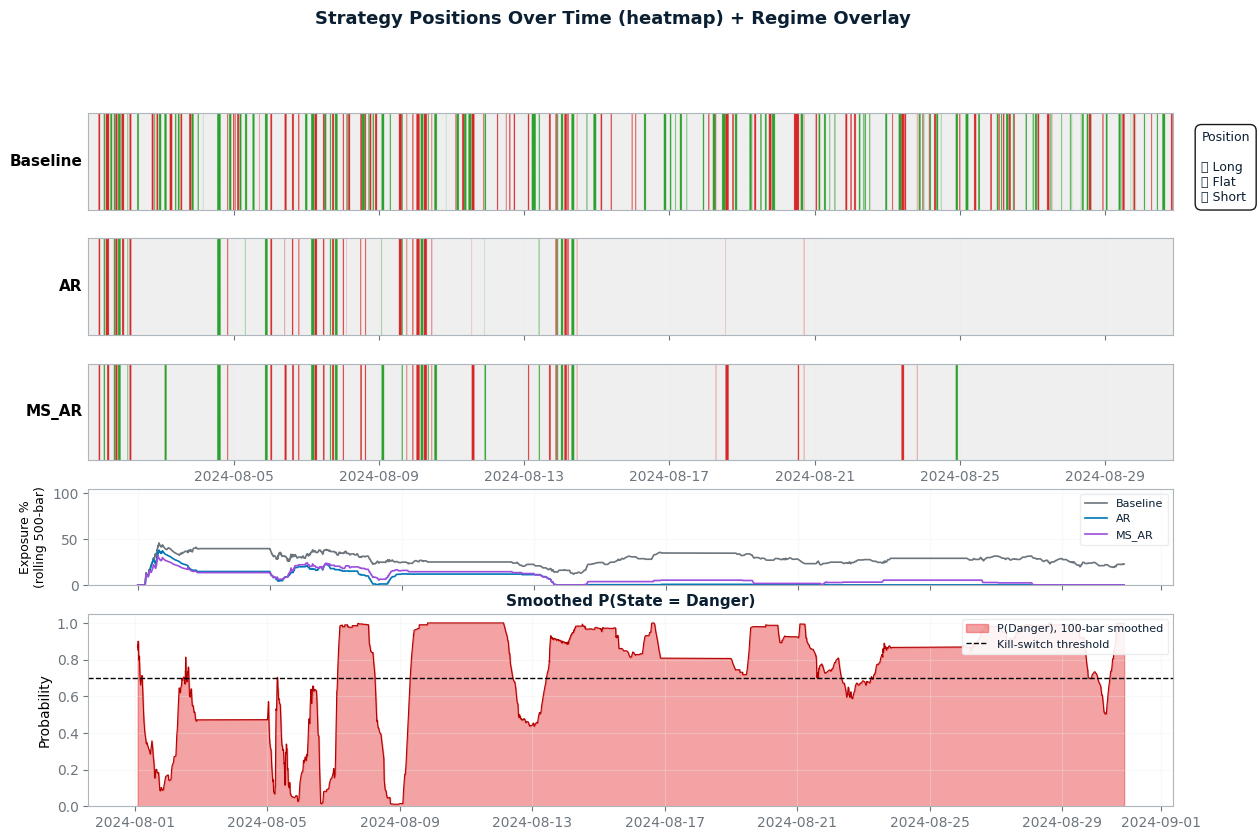

  [plot_markov_dynamics failed: TypeError: TEARSHEET.plot_markov_dynamics() got an unexpected keyword argument 'save_individual']
============================  202409  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -55.45         | -842.45        | -278.49        | -245.04        |
Annual Return (bps)            | -723.26        | -10989.46      | -3632.80       | -3196.51       |
Best Month (bps)               | -55.45         | -842.45        | -278.49        | -245.04        |
Worst Month (bps)              | -55.45         | -842.45        | -278.49        | -245.04        |
Positive Months %              | 0.00%          | 0.00%          | 0.00%          | 0.00%     

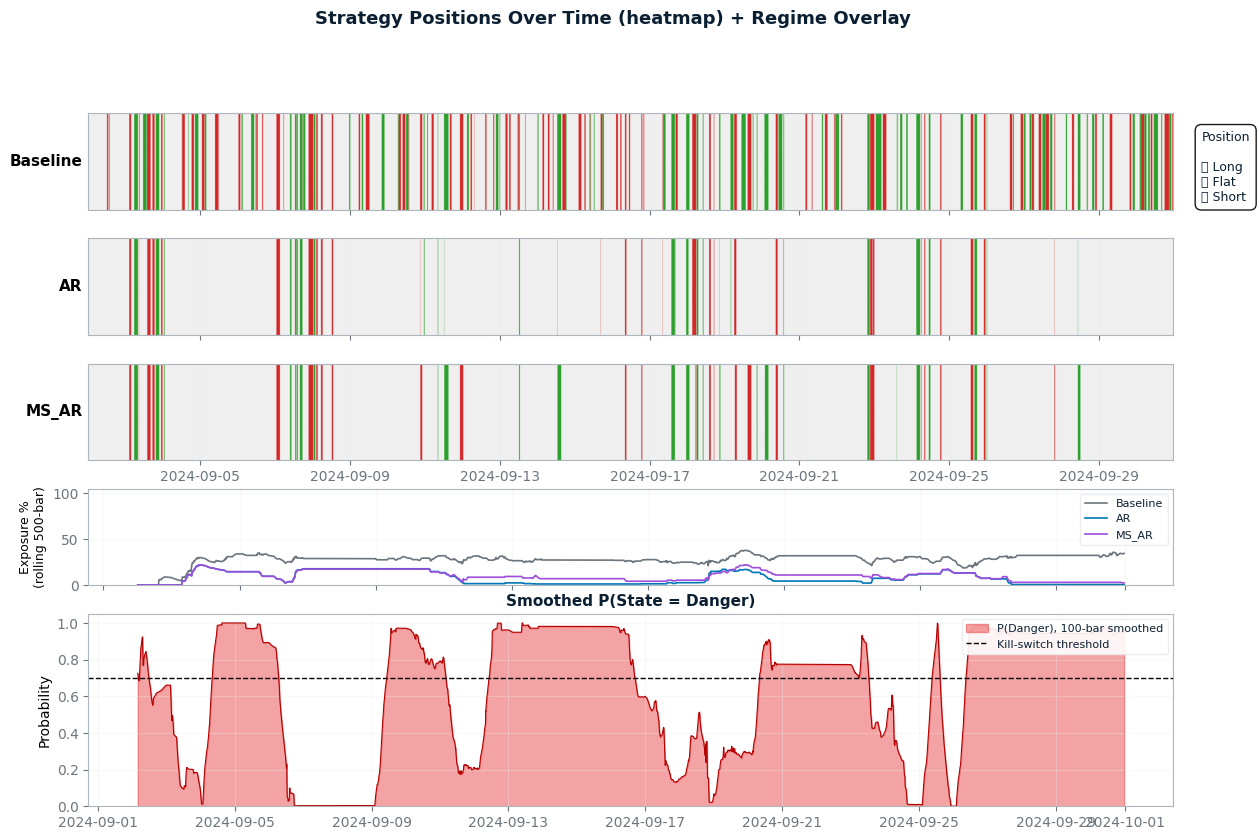

  [plot_markov_dynamics failed: TypeError: TEARSHEET.plot_markov_dynamics() got an unexpected keyword argument 'save_individual']
============================  202508  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 26.41          | -571.49        | -85.36         | -90.20         |
Annual Return (bps)            | 344.48         | -7454.83       | -1113.44       | -1176.57       |
Best Month (bps)               | 26.41          | -571.49        | -85.36         | -90.20         |
Worst Month (bps)              | 26.41          | -571.49        | -85.36         | -90.20         |
Positive Months %              | 100.00%        | 0.00%          | 0.00%          | 0.00%     

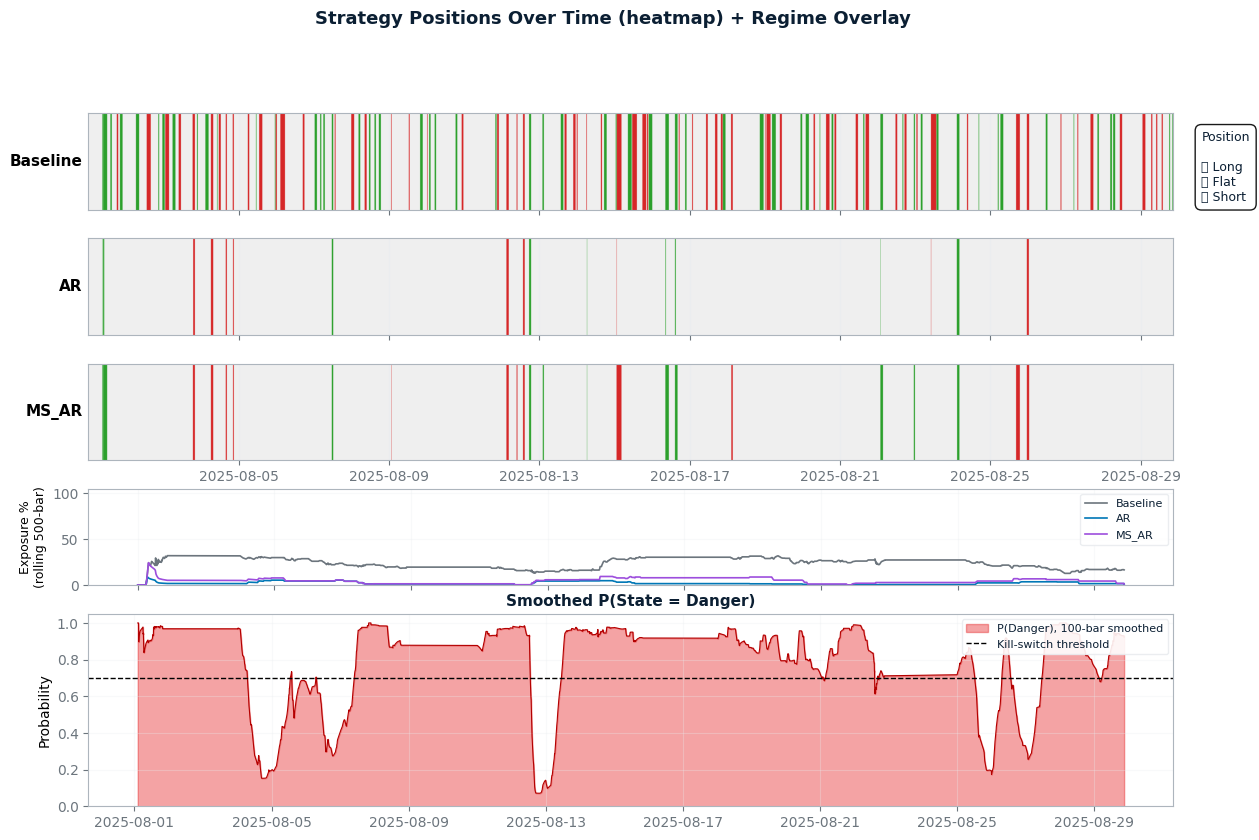

  [plot_markov_dynamics failed: TypeError: TEARSHEET.plot_markov_dynamics() got an unexpected keyword argument 'save_individual']


In [10]:
from pathlib import Path
from plotting import default_pdf_dir

PAIR_DIR = default_pdf_dir() / f'{PAIR_A}_{PAIR_B}'
PAIR_DIR.mkdir(parents=True, exist_ok=True)
print(f'PDFs -> {PAIR_DIR}')

for m, (bt, params, _) in runs.items():
    print(f'{"="*28}  {m}  {"="*28}')
    try:
        ts = TEARSHEET(
            bt,
            df_params  = params,
            save_pdf   = True,
            pdf_dir    = str(PAIR_DIR),
            pdf_prefix = f'{PAIR_A}_{PAIR_B}_{m}',
        )
        ts.generate_report()
        try:
            ts.plot_performance(save_individual=True)
        except Exception as e:
            print(f'  [plot_performance failed: {type(e).__name__}: {e}]')
        try:
            ts.plot_positions_and_regimes()
        except Exception as e:
            print(f'  [plot_positions_and_regimes failed: {type(e).__name__}: {e}]')
        try:
            ts.plot_markov_dynamics(save_individual=True)
        except Exception as e:
            print(f'  [plot_markov_dynamics failed: {type(e).__name__}: {e}]')
    except Exception as e:
        print(f'  [{m} fully failed: {type(e).__name__}: {e}]')


## Cross-month summary

PnL in bps, Sharpe annualised on the tick-clock (`252 × 24 × 60` bars/year, matches `MONTH` default), and one round-trip per `Target` flip cycle.


In [11]:
def annualised_sharpe(returns):
    r = returns.fillna(0)
    sd = r.std()
    return float(r.mean() / sd * np.sqrt(ANN_FACTOR)) if sd > 0 else 0.0


rows = []
for m, (bt, _, _) in runs.items():
    row = {'Month': m}
    for s in ['BuyHold', 'Baseline', 'AR', 'MS_AR']:
        r = bt[f'Return_{s}']
        row[f'{s}_PnL_bps'] = float(r.fillna(0).sum() * 1e4)
        row[f'{s}_Sharpe']  = annualised_sharpe(r)
        row[f'{s}_Trades']  = int((bt[f'Target_{s}'].diff().abs() > 0).sum() / 2)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Month')

print('\n=== PnL bps by month ===')
print(summary[[c for c in summary.columns if c.endswith('PnL_bps')]].round(1).to_string())

print('\n=== Sharpe (tick-clock annualised) ===')
print(summary[[c for c in summary.columns if c.endswith('Sharpe')]].round(2).to_string())

print('\n=== Round-trip trade counts ===')
print(summary[[c for c in summary.columns if c.endswith('Trades')]].to_string())

summary



=== PnL bps by month ===
        BuyHold_PnL_bps  Baseline_PnL_bps  AR_PnL_bps  MS_AR_PnL_bps
Month                                                               
202408            -45.8           -1136.1      -282.4         -315.1
202409            -55.4            -842.5      -278.5         -245.0
202508             26.4            -571.5       -85.4          -90.2

=== Sharpe (tick-clock annualised) ===
        BuyHold_Sharpe  Baseline_Sharpe  AR_Sharpe  MS_AR_Sharpe
Month                                                           
202408           -2.41           -88.97     -59.22        -46.88
202409           -4.32          -100.64     -67.77        -52.79
202508            3.38           -89.55     -34.90        -34.85

=== Round-trip trade counts ===
        BuyHold_Trades  Baseline_Trades  AR_Trades  MS_AR_Trades
Month                                                           
202408               0              193         48            54
202409               0              

,BuyHold_PnL_bps,BuyHold_Sharpe,BuyHold_Trades,Baseline_PnL_bps,Baseline_Sharpe,Baseline_Trades,AR_PnL_bps,AR_Sharpe,AR_Trades,MS_AR_PnL_bps,MS_AR_Sharpe,MS_AR_Trades
Month,,,,,,,,,,,,
202408,-45.839557,-2.406896,0,-1136.123178,-88.973588,193,-282.356058,-59.220646,48,-315.146230,-46.884473,54
202409,-55.445221,-4.316630,0,-842.450286,-100.637342,166,-278.489599,-67.769689,55,-245.044103,-52.788223,54
202508,26.408017,3.378628,0,-571.485812,-89.552403,122,-85.355947,-34.897962,18,-90.195508,-34.846223,23


### Per-day regime parameters

Each row in `runs[m][1]` is the per-day fit summary: bar count, $\beta$, regime $\sigma$, regime $\rho$, regime means and transition probabilities. Useful for sanity-checking the HMM and for the paper's tables.


In [12]:
for m, (_, params, _) in runs.items():
    print(f'\n=== {m}  per-day fits ===')
    print(params.round(4).to_string())



=== 202408  per-day fits ===
            Bars    Beta   Alpha  MR_Sigma  DR_Sigma  MR_Rho  DR_Rho   MR_Mu   DR_Mu  P_MR_MR  P_DR_DR
Date                                                                                                  
2024-08-01   259  0.9474  0.0617    0.0001    0.0003  0.9885  0.6347  0.0108 -0.0003      NaN   0.8382
2024-08-02   314  1.1676  0.1756    0.0001    0.0002  0.7449  0.8975  0.0003 -0.0012   0.8430      NaN
2024-08-05   727  1.0077  0.0944    0.0002    0.0004  0.9174  0.8956  0.0012  0.0001      NaN   0.9011
2024-08-06   477  0.0687 -0.3925    0.0002    0.0004  0.8749  0.9184 -0.0001 -0.0016   0.9633      NaN
2024-08-07   357  0.8045 -0.0161    0.0000    0.0002  0.0332  0.9367 -0.0001  0.0031   0.0000      NaN
2024-08-08   293  0.5528 -0.1355    0.0002    0.0004  0.8941  0.9367  0.0012  0.0022   0.9726      NaN
2024-08-09   201  0.3088 -0.2618    0.0000    0.0002  0.2196  0.9391 -0.0000 -0.0006   0.2245      NaN
2024-08-12   159  0.3280 -0.2511    0.0001 